<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-4-Nonholonomic-Mechanics/Untitled153.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Test for Nonholonomy**

**Learning Local First Integrals Test for Rolling Wheel Constraints**

We check nonholonomy of the Pfaffian system on $R^4$ with $q=(x,y,\psi,\phi)$:


$$\omega_1 = dx - \cos(\psi) d\phi$$
$$   \omega_2  = dy - \sin(\psi) d\phi.$$

step    1 | total=2.166e+02 | ann=2.402e-01 | span=9.283e-01 | det=2.155e+04 | var=1.473e+00
step  200 | total=3.725e+01 | ann=4.623e-01 | span=1.236e+00 | det=3.555e+03 | var=1.074e+00
step  400 | total=4.880e+01 | ann=3.821e-01 | span=1.453e+00 | det=4.696e+03 | var=1.711e+00
step  600 | total=1.002e+01 | ann=1.172e+00 | span=2.471e+00 | det=6.380e+02 | var=2.846e-01
step  800 | total=1.987e+01 | ann=1.709e+00 | span=3.757e+00 | det=1.441e+03 | var=1.734e-01
step 1000 | total=7.422e+00 | ann=1.671e+00 | span=3.886e+00 | det=1.864e+02 | var=2.343e-01
step 1200 | total=7.201e+00 | ann=2.238e+00 | span=4.488e+00 | det=4.746e+01 | var=2.144e-01
step 1400 | total=8.525e+00 | ann=2.307e+00 | span=4.881e+00 | det=1.337e+02 | var=1.685e-01
step 1600 | total=3.596e+01 | ann=2.894e+00 | span=6.733e+00 | det=2.633e+03 | var=1.651e-01
step 1800 | total=2.244e+01 | ann=2.931e+00 | span=7.655e+00 | det=1.185e+03 | var=1.427e-01
step 2000 | total=4.740e+01 | ann=2.439e+00 | span=5.870e+00 | det=3.9

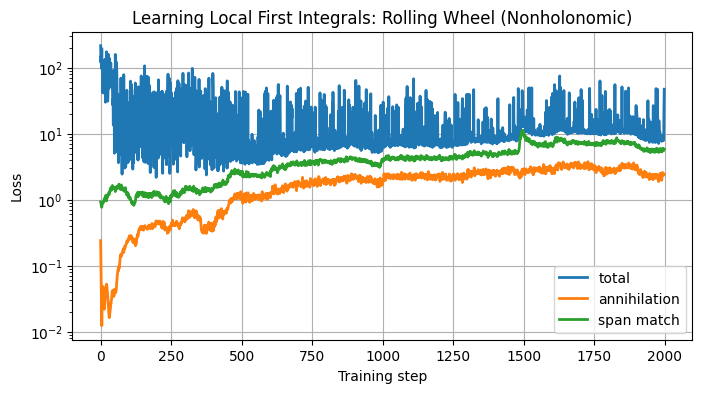


Interpretation:
For a holonomic system, one expects both the annihilation and span-matching losses to
be driven close to 0 with an invertible B(q), producing local first integrals h.
For the rolling wheel, the losses (especially span/ann simultaneously) typically
plateau above 0, reflecting the nonintegrability (nonholonomy) of D.


In [ ]:
# ============================================================
# Learning Local First Integrals (Method C) — Keras/Colab
# Check nonholonomy for rolling wheel constraints (nonholonomic)
#
# Coordinates: q = (x, y, psi, phi) in R^4
#   ω1 = dx - cos(psi) dphi
#   ω2 = dy - sin(psi) dphi
#
# Idea (holonomic case):
#   Learn h(q) = (h1(q), h2(q)) such that locally
#     D = ker(dh1) ∩ ker(dh2)
#   and span{dh1, dh2} matches span{ω1, ω2} via an invertible matrix B(q):
#     dh(q) ≈ B(q) ω(q)
#
# For the rolling wheel, no such first integrals exist globally/localy
# (distribution is not integrable), so the loss should NOT go to ~0.
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(0)
np.random.seed(0)

# ------------------------------------------------------------
# ω1, ω2 coefficients in coordinates (x,y,psi,phi)
# ωα = sum_j wα^j(q) dq_j
# ------------------------------------------------------------
@tf.function
def omega_coeffs(q):
    psi = q[:, 2]
    cospsi = tf.cos(psi)
    sinpsi = tf.sin(psi)
    # order: (x, y, psi, phi)
    w1 = tf.stack([tf.ones_like(psi), tf.zeros_like(psi), tf.zeros_like(psi), -cospsi], axis=1)
    w2 = tf.stack([tf.zeros_like(psi), tf.ones_like(psi), tf.zeros_like(psi), -sinpsi], axis=1)
    return tf.stack([w1, w2], axis=1)  # (B,2,4)

# ------------------------------------------------------------
# Analytic basis of D = ker ω1 ∩ ker ω2
# X1 = ∂/∂psi
# X2 = cos(psi) ∂/∂x + sin(psi) ∂/∂y + ∂/∂phi
# ------------------------------------------------------------
@tf.function
def D_basis(q):
    psi = q[:, 2]
    cospsi = tf.cos(psi)
    sinpsi = tf.sin(psi)

    X1 = tf.stack([
        tf.zeros_like(psi),
        tf.zeros_like(psi),
        tf.ones_like(psi),
        tf.zeros_like(psi)
    ], axis=1)  # (B,4)

    X2 = tf.stack([
        cospsi,
        sinpsi,
        tf.zeros_like(psi),
        tf.ones_like(psi)
    ], axis=1)  # (B,4)

    return X1, X2

# ------------------------------------------------------------
# Sampling q
# ------------------------------------------------------------
def sample_q(batch_size):
    x   = np.random.uniform(-1.0, 1.0, size=(batch_size, 1)).astype(np.float32)
    y   = np.random.uniform(-1.0, 1.0, size=(batch_size, 1)).astype(np.float32)
    psi = np.random.uniform(-np.pi, np.pi, size=(batch_size, 1)).astype(np.float32)
    phi = np.random.uniform(-1.0, 1.0, size=(batch_size, 1)).astype(np.float32)
    return np.concatenate([x, y, psi, phi], axis=1)

# ------------------------------------------------------------
# Networks: h(q) in R^2 and B(q) in R^{2x2}
# ------------------------------------------------------------
class HNet(tf.keras.Model):
    def __init__(self, width=64, depth=3):
        super().__init__()
        self.hidden = [tf.keras.layers.Dense(width, activation="tanh") for _ in range(depth)]
        self.out = tf.keras.layers.Dense(2, activation=None)  # (h1,h2)

    def call(self, q, training=False):
        x = q
        for layer in self.hidden:
            x = layer(x)
        return self.out(x)  # (B,2)

class BNet(tf.keras.Model):
    def __init__(self, width=64, depth=2):
        super().__init__()
        self.hidden = [tf.keras.layers.Dense(width, activation="tanh") for _ in range(depth)]
        self.out = tf.keras.layers.Dense(4, activation=None)  # 4 entries -> 2x2

    def call(self, q, training=False):
        x = q
        for layer in self.hidden:
            x = layer(x)
        raw = self.out(x)  # (B,4)
        B = tf.reshape(raw, (-1, 2, 2))  # (B,2,2)
        return B

# ------------------------------------------------------------
# Compute dh via autodiff: dh[b,alpha,j] = ∂ h_alpha / ∂ q_j
# ------------------------------------------------------------
@tf.function
def dh_of_q(hnet, q):
    with tf.GradientTape() as tape:
        tape.watch(q)
        h = hnet(q, training=True)  # (B,2)
    dh = tape.batch_jacobian(h, q)  # (B,2,4)
    return h, dh

# ------------------------------------------------------------
# Losses:
# 1) Annihilation: dh_alpha(Xi)=0 for Xi in D
# 2) Span match: dh ≈ B ω
# 3) Invertibility regularizer for B: det(B) away from 0
# 4) Nontriviality: encourage h to vary (avoid constant h)
# ------------------------------------------------------------
@tf.function
def batch_loss(hnet, bnet, q_batch, lam_span=1.0, mu_det=1e-2, nu_var=1e-3):
    w = omega_coeffs(q_batch)       # (B,2,4)
    X1, X2 = D_basis(q_batch)       # (B,4),(B,4)

    h, dh = dh_of_q(hnet, q_batch)  # h: (B,2), dh: (B,2,4)
    B = bnet(q_batch, training=True)  # (B,2,2)

    # ---- (1) Annihilation loss: sum_{alpha,i} | dh_alpha(Xi) |^2
    # dh_alpha(X) = <grad h_alpha, X> in coordinates = sum_j (∂h_alpha/∂q_j) X^j
    dhX1 = tf.reduce_sum(dh * tf.expand_dims(X1, axis=1), axis=2)  # (B,2)
    dhX2 = tf.reduce_sum(dh * tf.expand_dims(X2, axis=1), axis=2)  # (B,2)
    L_ann = tf.reduce_mean(tf.reduce_sum(tf.square(dhX1) + tf.square(dhX2), axis=1))

    # ---- (2) Span-matching loss: dh - B ω (Frobenius norm)
    # (B ω)[b,i,j] = sum_alpha B[b,i,alpha] * w[b,alpha,j]
    Bw = tf.einsum("bia,baj->bij", B, w)  # (B,2,4)
    L_span = tf.reduce_mean(tf.reduce_sum(tf.square(dh - Bw), axis=[1, 2]))

    # ---- (3) Invertibility regularizer for B
    detB = B[:, 0, 0] * B[:, 1, 1] - B[:, 0, 1] * B[:, 1, 0]
    L_det = tf.reduce_mean(1.0 / (tf.square(detB) + 1e-6))

    # ---- (4) Nontriviality: encourage variation of h within the batch
    # (prevents constant h + B≈0 from being a low-loss attractor)
    h_centered = h - tf.reduce_mean(h, axis=0, keepdims=True)
    var = tf.reduce_mean(tf.reduce_sum(tf.square(h_centered), axis=1))
    L_var = 1.0 / (var + 1e-6)

    # Total
    L = L_ann + lam_span * L_span + mu_det * L_det + nu_var * L_var
    return L, L_ann, L_span, L_det, L_var

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
def train_first_integrals_test(
    steps=2000,
    batch_size=256,
    lr=1e-3,
    lam_span=1.0,
    mu_det=1e-2,
    nu_var=1e-3,
    print_every=200,
):
    hnet = HNet(width=64, depth=3)
    bnet = BNet(width=64, depth=2)
    opt = tf.keras.optimizers.Adam(lr)

    # Build
    _ = hnet(tf.convert_to_tensor(sample_q(4)))
    _ = bnet(tf.convert_to_tensor(sample_q(4)))

    hist = {"total": [], "ann": [], "span": [], "det": [], "var": []}

    for step in range(1, steps + 1):
        q = tf.convert_to_tensor(sample_q(batch_size))

        with tf.GradientTape() as tape:
            L, L_ann, L_span, L_det, L_var = batch_loss(
                hnet, bnet, q,
                lam_span=tf.constant(lam_span, tf.float32),
                mu_det=tf.constant(mu_det, tf.float32),
                nu_var=tf.constant(nu_var, tf.float32),
            )
        vars_ = hnet.trainable_variables + bnet.trainable_variables
        grads = tape.gradient(L, vars_)
        opt.apply_gradients(zip(grads, vars_))

        hist["total"].append(float(L.numpy()))
        hist["ann"].append(float(L_ann.numpy()))
        hist["span"].append(float(L_span.numpy()))
        hist["det"].append(float(L_det.numpy()))
        hist["var"].append(float(L_var.numpy()))

        if step % print_every == 0 or step == 1:
            print(f"step {step:4d} | total={L.numpy():.3e} | ann={L_ann.numpy():.3e} | span={L_span.numpy():.3e} | det={L_det.numpy():.3e} | var={L_var.numpy():.3e}")

    # Final evaluation on test set
    q_test = tf.convert_to_tensor(sample_q(8000))
    L, L_ann, L_span, L_det, L_var = batch_loss(
        hnet, bnet, q_test,
        lam_span=tf.constant(lam_span, tf.float32),
        mu_det=tf.constant(mu_det, tf.float32),
        nu_var=tf.constant(nu_var, tf.float32),
    )
    print("\nFinal evaluation (8000 test points):")
    print(f"  total={L.numpy():.3e} | ann={L_ann.numpy():.3e} | span={L_span.numpy():.3e} | det={L_det.numpy():.3e} | var={L_var.numpy():.3e}")

    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(hist["total"], label="total", linewidth=2)
    plt.plot(hist["ann"], label="annihilation", linewidth=2)
    plt.plot(hist["span"], label="span match", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Learning Local First Integrals: Rolling Wheel (Nonholonomic)")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("\nInterpretation:")
    print("For a holonomic system, one expects both the annihilation and span-matching losses to")
    print("be driven close to 0 with an invertible B(q), producing local first integrals h.")
    print("For the rolling wheel, the losses (especially span/ann simultaneously) typically")
    print("plateau above 0, reflecting the nonintegrability (nonholonomy) of D.")

    return hnet, bnet, hist

# Run training
hnet, bnet, hist = train_first_integrals_test(
    steps=2000, batch_size=256, lr=1e-3,
    lam_span=1.0, mu_det=1e-2, nu_var=1e-3,
    print_every=200
)
